# Duck vs Chicken — Transfer Learning

> **Local paths used:**  
> `C:\Users\sowmy\Downloads\SEM4\AML\Assignment5\data\chicken_images` → label **0 (chicken)**  
> `C:\Users\sowmy\Downloads\SEM4\AML\Assignment5\data\duck_images`    → label **1 (duck)**

## Step 1 — Imports & Reproducibility

In [1]:
import os, shutil, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import timm                                         # EfficientNet weights
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

c:\Users\sowmy\Downloads\SEM4\AML\Assignment5\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Step 2 — Data Paths & Organised Split

We read images from the two **unlabelled** local folders, assign labels by folder name, and programmatically create train / val / test splits (70 / 15 / 15 %).

In [2]:
# -- Local Windows paths --
CHICKEN_DIR = r'C:\Users\sowmy\Downloads\SEM4\AML\Assignment5\data\chicken_images'
DUCK_DIR    = r'C:\Users\sowmy\Downloads\SEM4\AML\Assignment5\data\duck_images'

ORGANISED_DIR = r'C:\Users\sowmy\Downloads\SEM4\AML\Assignment5\data\organised'
CLASSES       = ['chicken', 'duck']          # index 0 = chicken, 1 = duck
CLASS_TO_IDX  = {c: i for i, c in enumerate(CLASSES)}
SPLITS        = {'train': 0.70, 'val': 0.15, 'test': 0.15}

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def collect_images(folder):
    """Return list of valid image paths inside a folder."""
    return sorted([
        str(p) for p in Path(folder).iterdir()
        if p.suffix.lower() in IMG_EXTENSIONS
    ])

def build_organised_split(src_dir, cls_name, organised_root, splits, seed=42):
    """Copy images into organised_root/{split}/{cls_name}/."""
    imgs = collect_images(src_dir)
    random.seed(seed)
    random.shuffle(imgs)
    n = len(imgs)
    n_train = int(n * splits['train'])
    n_val   = int(n * splits['val'])
    buckets  = {
        'train': imgs[:n_train],
        'val'  : imgs[n_train : n_train + n_val],
        'test' : imgs[n_train + n_val:]
    }
    for split, paths in buckets.items():
        dst = Path(organised_root) / split / cls_name
        dst.mkdir(parents=True, exist_ok=True)
        for p in paths:
            shutil.copy(p, dst / Path(p).name)
    return {k: len(v) for k, v in buckets.items()}

# Build organised structure
print('Building organised split...')
for cls, src in zip(CLASSES, [CHICKEN_DIR, DUCK_DIR]):
    counts = build_organised_split(src, cls, ORGANISED_DIR, SPLITS)
    print(f'  {cls:8s}  →  ', counts)

print('\nDone! Organised structure:')
for split in SPLITS:
    for cls in CLASSES:
        p = Path(ORGANISED_DIR) / split / cls
        print(f'  {split}/{cls}: {len(list(p.iterdir()))} images')

Building organised split...
  chicken   →   {'train': 105, 'val': 22, 'test': 23}
  duck      →   {'train': 105, 'val': 22, 'test': 23}

Done! Organised structure:
  train/chicken: 105 images
  train/duck: 105 images
  val/chicken: 22 images
  val/duck: 22 images
  test/chicken: 23 images
  test/duck: 23 images


## Step 3 — Data Augmentation & Transforms

EfficientNet-B4 expects **380×380** inputs. We apply aggressive augmentation on the **training set** to fight overfitting on our small 150-image-per-class dataset.

In [3]:
IMG_SIZE   = 380          # EfficientNet-B4 native resolution
MEAN       = [0.485, 0.456, 0.406]   # ImageNet stats
STD        = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE + 30, IMG_SIZE + 30)),       # over-crop then crop
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1)),      # Cutout-style regularisation
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

print('Train transform pipeline:')
print(train_transform)
print('\nEval transform pipeline:')
print(eval_transform)

Train transform pipeline:
Compose(
    Resize(size=(410, 410), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(380, 380), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.15)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
    RandomGrayscale(p=0.05)
    RandomPerspective(p=0.3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0, inplace=False)
)

Eval transform pipeline:
Compose(
    Resize(size=(380, 380), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Step 4 — Dataset & DataLoaders

In [4]:
from torchvision.datasets import ImageFolder

BATCH_SIZE  = 16          # keep small to fit 300 images comfortably on GPU
NUM_WORKERS = 2

train_ds = ImageFolder(root=str(Path(ORGANISED_DIR) / 'train'),
                       transform=train_transform)
val_ds   = ImageFolder(root=str(Path(ORGANISED_DIR) / 'val'),
                       transform=eval_transform)
test_ds  = ImageFolder(root=str(Path(ORGANISED_DIR) / 'test'),
                       transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = train_ds.classes   # ['chicken', 'duck']
print(f'Classes : {CLASS_NAMES}  (idx map: {train_ds.class_to_idx})')
print(f'Train   : {len(train_ds)} images | {len(train_loader)} batches')
print(f'Val     : {len(val_ds)}   images | {len(val_loader)}   batches')
print(f'Test    : {len(test_ds)}  images | {len(test_loader)}  batches')

Classes : ['chicken', 'duck']  (idx map: {'chicken': 0, 'duck': 1})
Train   : 210 images | 14 batches
Val     : 44   images | 3   batches
Test    : 46  images | 3  batches


## Step 5 — Sample Image Grid

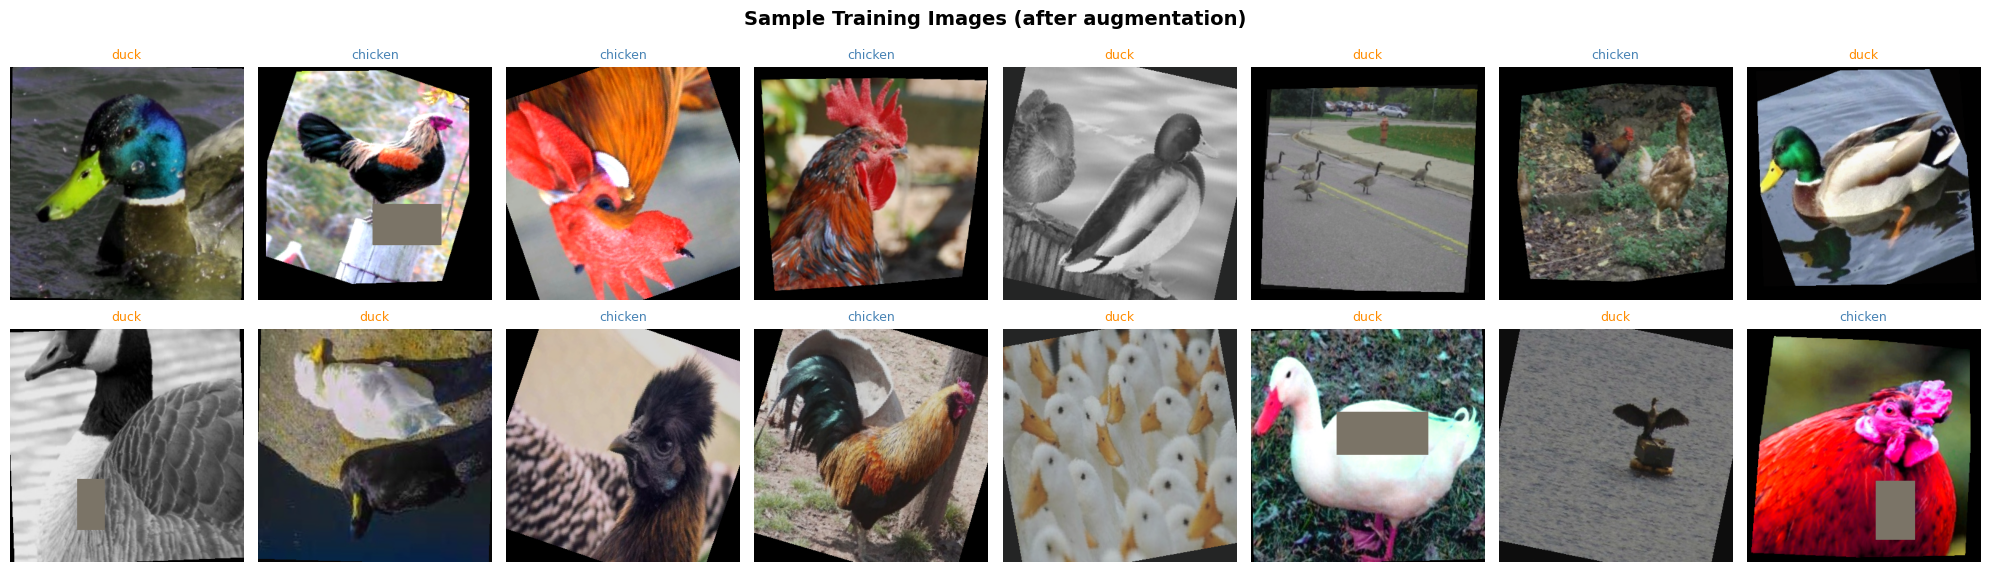

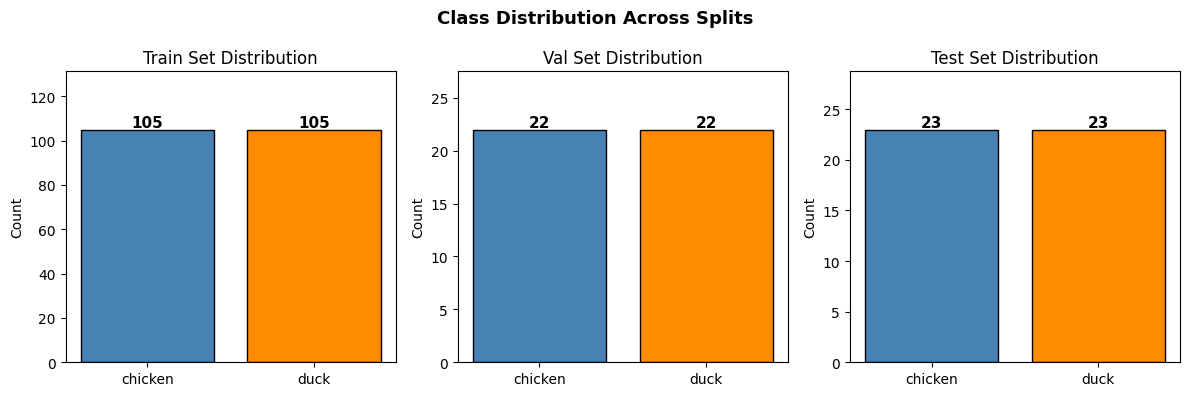

In [5]:
def denormalize(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Grab one batch from train loader
imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Sample Training Images (after augmentation)', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs): break
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9,
                 color='steelblue' if labels[i] == 0 else 'darkorange')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Class distribution bar chart
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (split, ds) in zip(axes, [('Train', train_ds), ('Val', val_ds), ('Test', test_ds)]):
    counts = [ds.targets.count(i) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, counts, color=['steelblue', 'darkorange'], edgecolor='k')
    ax.bar_label(bars, fontsize=11, fontweight='bold')
    ax.set_title(f'{split} Set Distribution', fontsize=12)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts) * 1.25)
plt.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Model: EfficientNet-B4 with Custom Head

**Why EfficientNet-B4?**
- Compound scaling (depth + width + resolution) → superior accuracy per parameter vs ResNet/VGG
- B4 variant reaches **~83% Top-1 on ImageNet** while staying manageable on a T4 GPU
- Pre-trained on ImageNet → rich low-level feature detectors reusable for bird classification

**Fine-tuning strategy:**  
1. Phase 1 (epochs 1–10): Freeze backbone, train classifier head only → warm-up
2. Phase 2 (epochs 11–20): Unfreeze last 2 blocks + head → targeted fine-tuning


In [6]:
def build_model(num_classes=2, pretrained=True):
    """
    Load EfficientNet-B4 from timm with a custom two-class head.
    Returns: model with backbone initially frozen.
    """
    model = timm.create_model(
        'efficientnet_b4',
        pretrained=pretrained,
        num_classes=num_classes,   # replace the default 1000-class head
    )

    # --- Phase 1: freeze all params except the head ---
    for name, param in model.named_parameters():
        if 'classifier' not in name:   # timm: final layer is model.classifier
            param.requires_grad = False

    return model


def unfreeze_last_n_blocks(model, n=2):
    """Unfreeze the last n EfficientNet blocks + the head."""
    blocks = list(model.blocks)          # list of Sequential stages
    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True
    # conv_head + bn2 (final BN before classifier)
    for param in model.conv_head.parameters():
        param.requires_grad = True
    for param in model.bn2.parameters():
        param.requires_grad = True


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


def count_trainable(model):
    total      = sum(p.numel() for p in model.parameters())
    trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable params : {trainable:>10,d}  ({100*trainable/total:.1f}% of {total:,d})')


model = build_model(num_classes=2, pretrained=True).to(DEVICE)
print('Phase 1 — Head only:')
count_trainable(model)

Phase 1 — Head only:
  Trainable params :      3,586  (0.0% of 17,552,202)


## Step 7 — Training Utilities

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    """One epoch of mixed-precision training."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Returns (loss, accuracy) on a loader."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs      = model(imgs)
        loss         = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, 100 * correct / total


class EarlyStopping:
    """Stop training if validation loss does not improve after `patience` epochs."""
    def __init__(self, patience=7, min_delta=1e-4, path='best_model.pth'):
        self.patience  = patience
        self.min_delta = min_delta
        self.path      = path
        self.counter   = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            return False                 # do not stop
        self.counter += 1
        return self.counter >= self.patience   # stop?


def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-s', ms=4, label='Val')
    ax1.set_title(f'{title} — Loss', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-o', ms=4, label='Train')
    ax2.plot(epochs, history['val_acc'],   'r-s', ms=4, label='Val')
    ax2.set_title(f'{title} — Accuracy', fontsize=12)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)

    # Mark phase transitions if stored
    for key, ep, col in history.get('phase_marks', []):
        ax1.axvline(ep, color=col, linestyle=':', linewidth=1.5, label=key)
        ax2.axvline(ep, color=col, linestyle=':', linewidth=1.5, label=key)
    ax1.legend(); ax2.legend()

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Utilities ready')

Utilities ready


## Step 8 — Progressive Fine-Tuning Training Loop

| Phase | Epochs | Layers Unfrozen | LR |
|-------|--------|-----------------|----|
| 1 — Head warm-up | 1–10 | Classifier head only | 1e-3 |
| 2 — Partial unfreeze | 11–20 | Last 2 blocks + head | 5e-4 |


In [8]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
PHASE_EPOCHS  = [10, 10]              # epochs per phase
PHASE_LR      = [1e-3, 5e-4]         # LR per phase
WEIGHT_DECAY  = 1e-4
PATIENCE      = 7
CHECKPOINT    = 'best_model.pth'

criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler        = torch.cuda.amp.GradScaler()
early_stop    = EarlyStopping(patience=PATIENCE, path=CHECKPOINT)

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'phase_marks': []}

global_epoch  = 0
stopped_early = False

phase_setup = [
    ('Phase 1 — Head warm-up',     lambda m: None,                         PHASE_EPOCHS[0], PHASE_LR[0]),
    ('Phase 2 — Partial unfreeze', lambda m: unfreeze_last_n_blocks(m, 2), PHASE_EPOCHS[1], PHASE_LR[1]),
]

for phase_name, phase_fn, n_epochs, lr in phase_setup:
    print(f'\n{"="*60}')
    print(f'  {phase_name}')
    print(f'{"="*60}')
    phase_fn(model)
    count_trainable(model)
    history['phase_marks'].append((phase_name, global_epoch + 1,
                                   'green' if '1' in phase_name else 'orange'))

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)

    for epoch in range(1, n_epochs + 1):
        global_epoch += 1
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        print(f'  Epoch {global_epoch:3d} | '
              f'Train Loss {tr_loss:.4f}  Acc {tr_acc:.1f}% | '
              f'Val Loss {va_loss:.4f}  Acc {va_acc:.1f}% | '
              f'LR {scheduler.get_last_lr()[0]:.2e}')

        if early_stop(va_loss, model):
            print(f'Early stopping at global epoch {global_epoch}')
            stopped_early = True
            break

    if stopped_early:
        break

# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
print(f'\nBest model loaded from {CHECKPOINT}  (best val loss: {early_stop.best_loss:.4f})')


  Phase 1 — Head warm-up
  Trainable params :      3,586  (0.0% of 17,552,202)
  Epoch   1 | Train Loss 0.7483  Acc 63.3% | Val Loss 0.6711  Acc 63.6% | LR 9.76e-04
  Epoch   2 | Train Loss 0.7065  Acc 66.7% | Val Loss 0.5322  Acc 77.3% | LR 9.05e-04
  Epoch   3 | Train Loss 0.5976  Acc 75.2% | Val Loss 0.4734  Acc 81.8% | LR 7.96e-04
  Epoch   4 | Train Loss 0.5691  Acc 75.2% | Val Loss 0.4254  Acc 84.1% | LR 6.58e-04
  Epoch   5 | Train Loss 0.4572  Acc 84.3% | Val Loss 0.3853  Acc 88.6% | LR 5.05e-04
  Epoch   6 | Train Loss 0.4909  Acc 81.4% | Val Loss 0.3822  Acc 90.9% | LR 3.52e-04
  Epoch   7 | Train Loss 0.5098  Acc 80.5% | Val Loss 0.3721  Acc 93.2% | LR 2.14e-04
  Epoch   8 | Train Loss 0.4980  Acc 81.0% | Val Loss 0.3687  Acc 90.9% | LR 1.05e-04
  Epoch   9 | Train Loss 0.4229  Acc 84.3% | Val Loss 0.3627  Acc 93.2% | LR 3.42e-05
  Epoch  10 | Train Loss 0.4806  Acc 83.3% | Val Loss 0.3771  Acc 88.6% | LR 1.00e-05

  Phase 2 — Partial unfreeze
  Trainable params : 13,916,21

## Step 9 — Training Curves

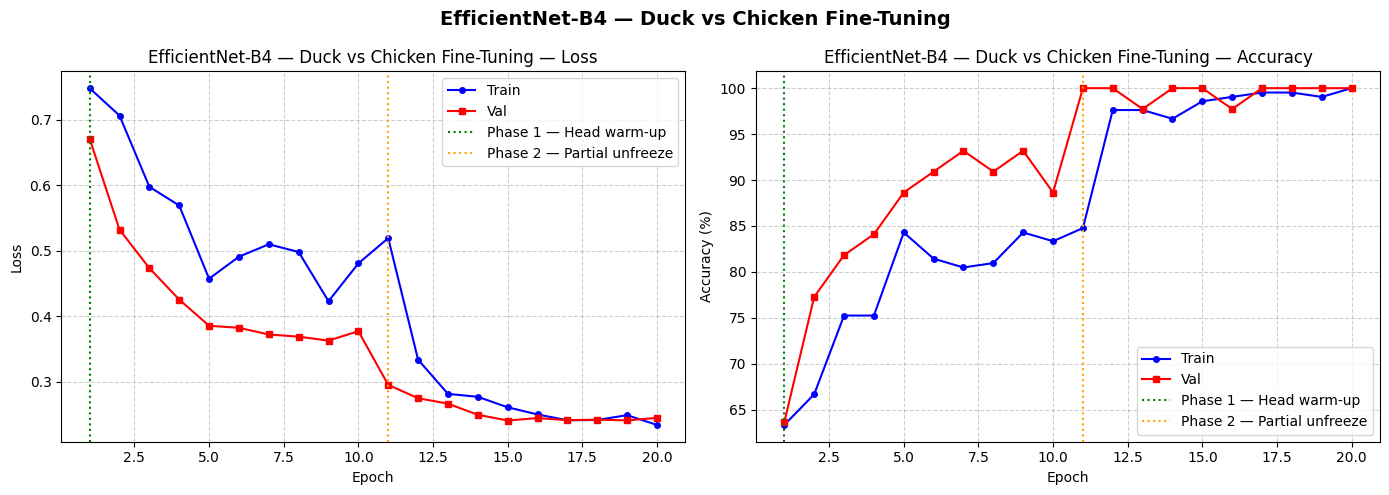

In [9]:
plot_history(history, title='EfficientNet-B4 — Duck vs Chicken Fine-Tuning')

## Step 10 — Comprehensive Evaluation on Test Set

In [10]:
@torch.no_grad()
def get_predictions(model, loader):
    """Return (true labels, predicted labels, softmax probabilities)."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = probs.argmax(1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.numpy())
        all_probs.extend(probs.numpy())
    return (np.array(all_labels),
            np.array(all_preds),
            np.array(all_probs))


y_true, y_pred, y_prob = get_predictions(model, test_loader)

# ── 10a. Classification Report ────────────────────────────────────────────────
print('=' * 55)
print('CLASSIFICATION REPORT — Test Set')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

CLASSIFICATION REPORT — Test Set
              precision    recall  f1-score   support

     chicken     0.9565    0.9565    0.9565        23
        duck     0.9565    0.9565    0.9565        23

    accuracy                         0.9565        46
   macro avg     0.9565    0.9565    0.9565        46
weighted avg     0.9565    0.9565    0.9565        46



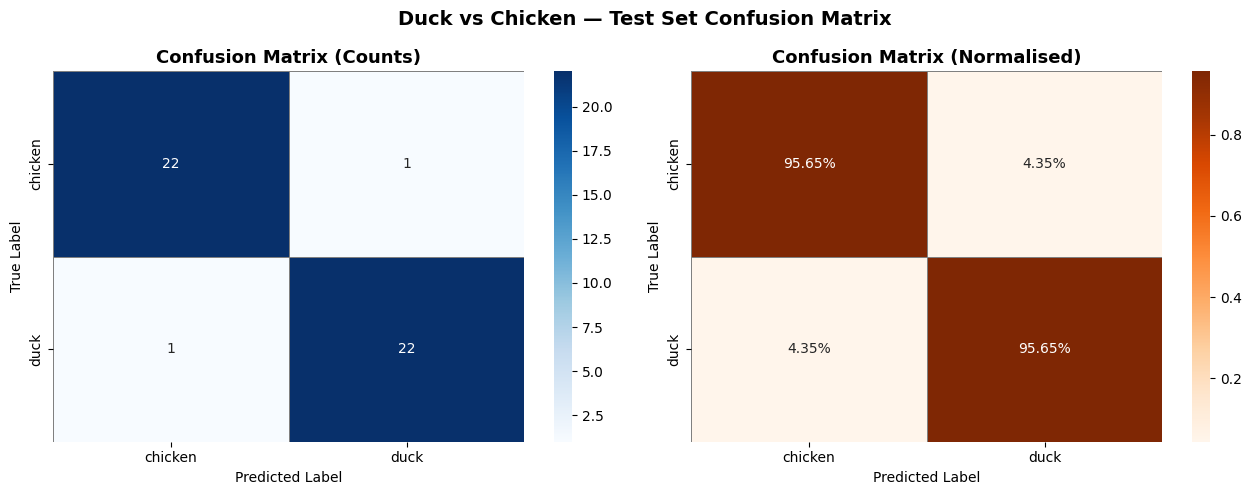

In [11]:
# ── 10b. Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.suptitle('Duck vs Chicken — Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

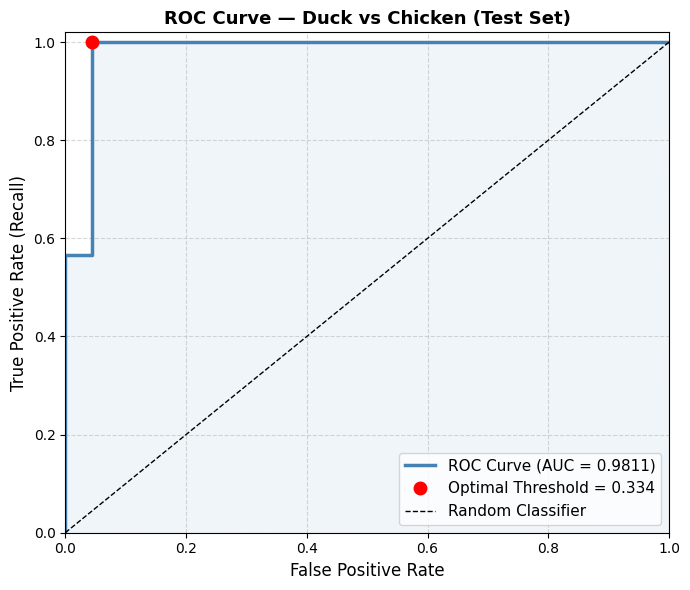

AUC-ROC: 0.9811   |   Optimal threshold: 0.3337


In [12]:
# ── 10c. ROC Curve ────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])   # positive class = duck (1)
roc_auc              = auc(fpr, tpr)

# Youden's J → optimal threshold
j_scores     = tpr - fpr
opt_idx      = np.argmax(j_scores)
opt_threshold = thresholds[opt_idx]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot(fpr[opt_idx], tpr[opt_idx], 'ro', ms=9,
        label=f'Optimal Threshold = {opt_threshold:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Duck vs Chicken (Test Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}   |   Optimal threshold: {opt_threshold:.4f}')

## Step 11 — Grad-CAM Visualisation

Grad-CAM highlights the image regions that most influenced the model's decision — a great way to verify the model is actually looking at the bird and not spurious background features.

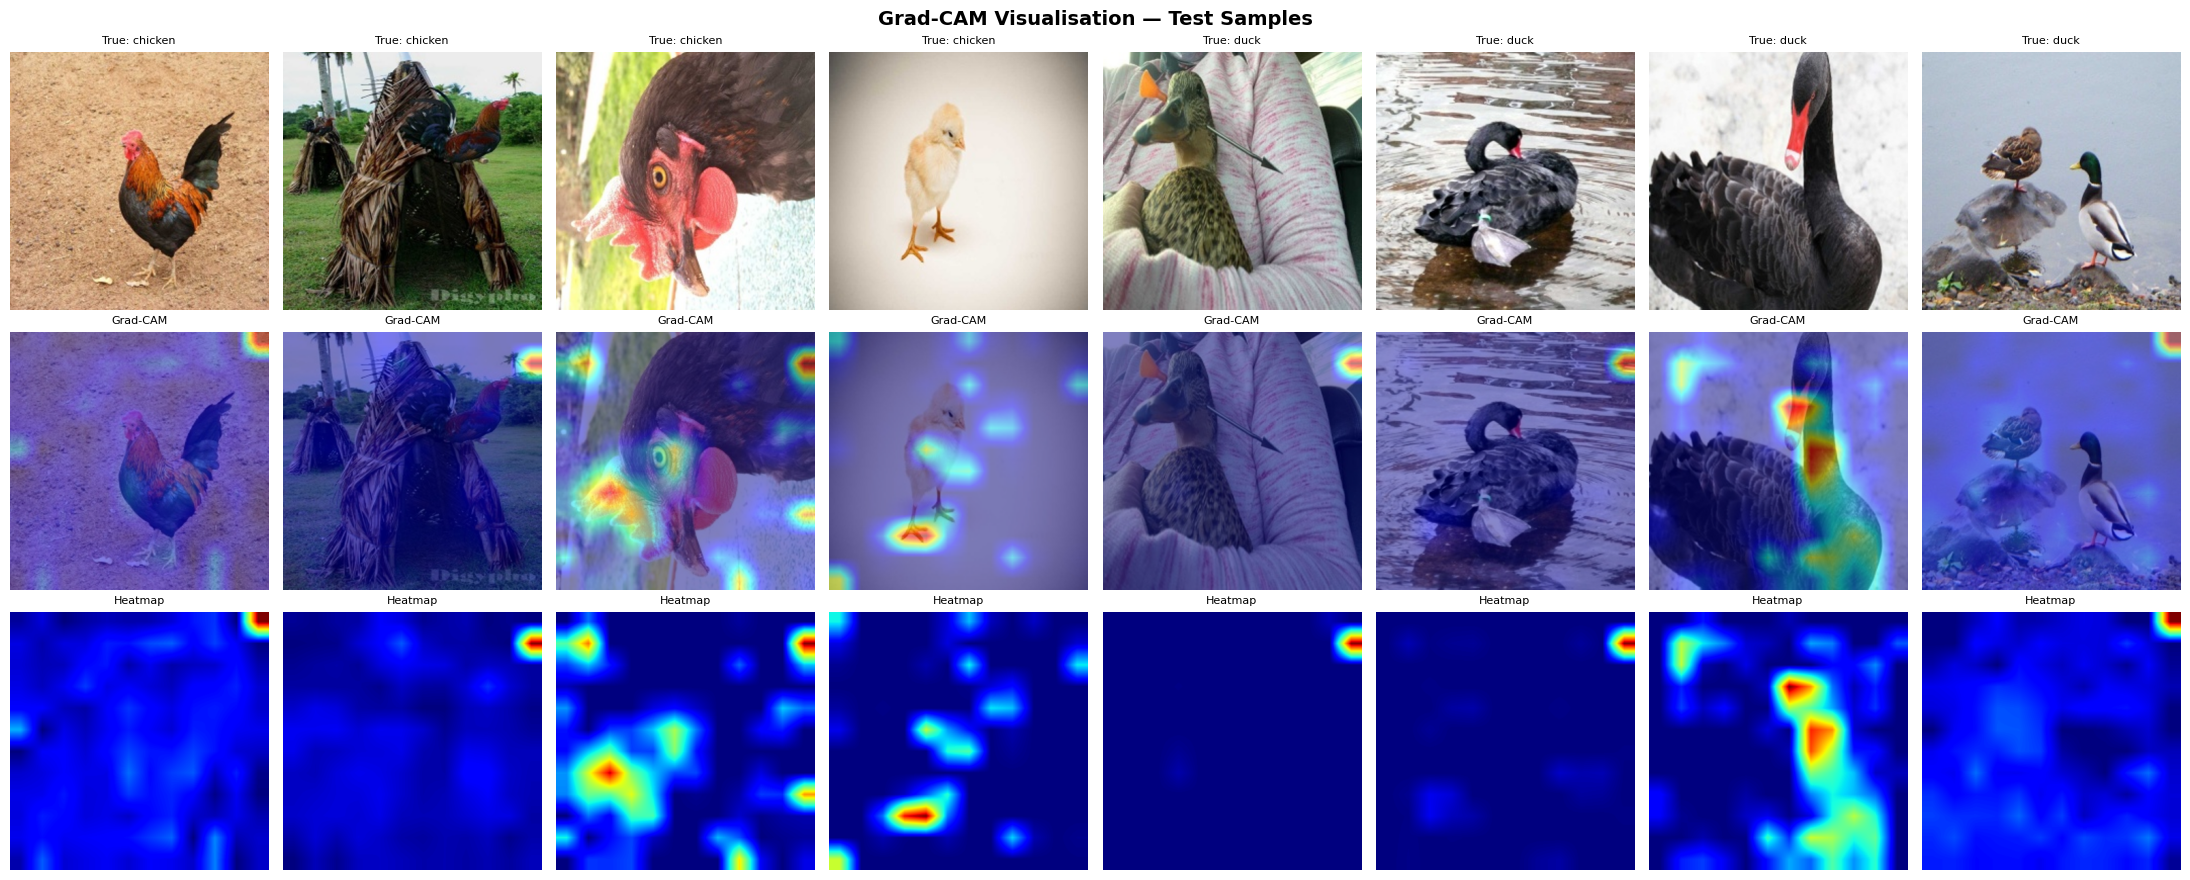

In [13]:
# Target layer = last conv block of EfficientNet-B4
target_layers = [model.blocks[-1][-1].conv_pwl]   # last pointwise conv

cam = GradCAM(model=model, target_layers=target_layers)

# Pick 8 test images (4 correct + 4 can be wrong too)
n_show     = 8
test_imgs_raw = []
test_imgs_t   = []
test_lbls     = []

for cls_idx, cls in enumerate(CLASS_NAMES):
    cls_folder = Path(ORGANISED_DIR) / 'test' / cls
    img_paths  = sorted(cls_folder.iterdir())[:n_show // 2]
    for p in img_paths:
        raw = np.array(Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))) / 255.0
        test_imgs_raw.append(raw.astype(np.float32))
        test_imgs_t.append(eval_transform(Image.open(p).convert('RGB')))
        test_lbls.append(cls_idx)

input_tensor = torch.stack(test_imgs_t).to(DEVICE)

fig, axes = plt.subplots(3, n_show, figsize=(22, 9))
fig.suptitle('Grad-CAM Visualisation — Test Samples', fontsize=14, fontweight='bold')

for i in range(n_show):
    grayscale_cam = cam(
        input_tensor=input_tensor[i:i+1],
        targets=[ClassifierOutputTarget(test_lbls[i])]
    )[0]

    cam_image = show_cam_on_image(test_imgs_raw[i], grayscale_cam, use_rgb=True)

    # Row 0: original
    axes[0, i].imshow(test_imgs_raw[i])
    axes[0, i].set_title(f'True: {CLASS_NAMES[test_lbls[i]]}', fontsize=8)
    axes[0, i].axis('off')

    # Row 1: Grad-CAM
    axes[1, i].imshow(cam_image)
    axes[1, i].set_title('Grad-CAM', fontsize=8)
    axes[1, i].axis('off')

    # Row 2: heatmap only
    axes[2, i].imshow(grayscale_cam, cmap='jet')
    axes[2, i].set_title('Heatmap', fontsize=8)
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## Step 12 — Misclassified Samples Analysis

Total misclassified: 2 / 46


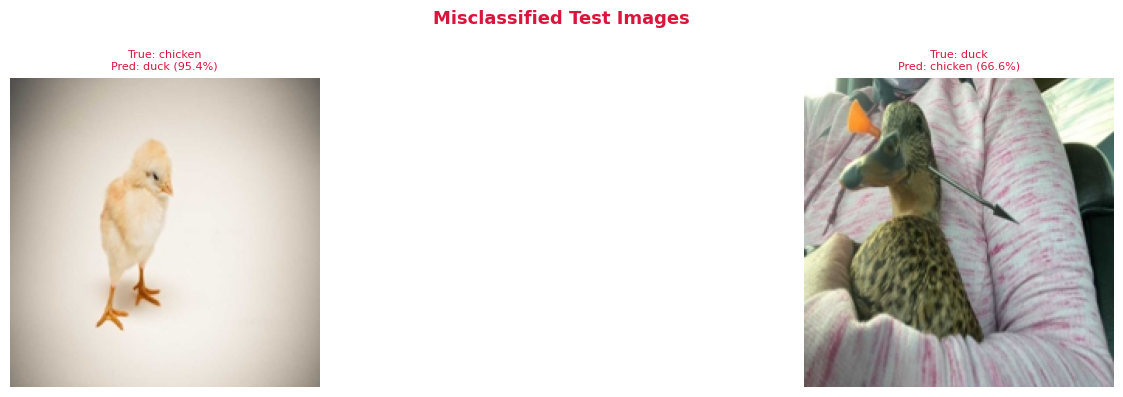

In [14]:
misclassified_indices = np.where(y_pred != y_true)[0]
print(f'Total misclassified: {len(misclassified_indices)} / {len(y_true)}')

if len(misclassified_indices) > 0:
    n_show = min(8, len(misclassified_indices))
    sample  = misclassified_indices[:n_show]

    # Rebuild a flat list of test image paths
    test_paths = [p for p, _ in test_ds.samples]

    fig, axes = plt.subplots(1, n_show, figsize=(20, 4))
    fig.suptitle('Misclassified Test Images', fontsize=13, fontweight='bold', color='crimson')

    if n_show == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample):
        img = Image.open(test_paths[idx]).convert('RGB').resize((200, 200))
        ax.imshow(img)
        confidence = y_prob[idx, y_pred[idx]] * 100
        ax.set_title(
            f'True: {CLASS_NAMES[y_true[idx]]}\n'
            f'Pred: {CLASS_NAMES[y_pred[idx]]} ({confidence:.1f}%)',
            fontsize=8, color='crimson'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Perfect classification — no misclassified test images!')

## Step 13 — Final Summary

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_acc  = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average='weighted') * 100
recall    = recall_score(y_true, y_pred, average='weighted') * 100
f1        = f1_score(y_true, y_pred, average='weighted') * 100

_, val_acc_best  = evaluate(model, val_loader, criterion)

print('\n' + '=' * 55)
print('FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Model           : EfficientNet-B4 (timm, ImageNet pre-trained)')
print(f'  Fine-tune phases: 3 (head → partial → full)')
print(f'  Total epochs    : {global_epoch}')
print(f'  Best Val Loss   : {early_stop.best_loss:.4f}')
print(f'  Val Accuracy    : {val_acc_best:.2f}%')
print(f'  Test Accuracy   : {test_acc:.2f}%')
print(f'  Weighted Precision : {precision:.2f}%')
print(f'  Weighted Recall    : {recall:.2f}%')
print(f'  Weighted F1-Score  : {f1:.2f}%')
print(f'  AUC-ROC            : {roc_auc:.4f}')
print('=' * 55)
print('\nFull Classification Report:')
print(classification_report(y_true, y_pred,
                             target_names=CLASS_NAMES, digits=4))


FINAL RESULTS SUMMARY
  Model           : EfficientNet-B4 (timm, ImageNet pre-trained)
  Fine-tune phases: 3 (head → partial → full)
  Total epochs    : 20
  Best Val Loss   : 0.2406
  Val Accuracy    : 100.00%
  Test Accuracy   : 95.65%
  Weighted Precision : 95.65%
  Weighted Recall    : 95.65%
  Weighted F1-Score  : 95.65%
  AUC-ROC            : 0.9811

Full Classification Report:
              precision    recall  f1-score   support

     chicken     0.9565    0.9565    0.9565        23
        duck     0.9565    0.9565    0.9565        23

    accuracy                         0.9565        46
   macro avg     0.9565    0.9565    0.9565        46
weighted avg     0.9565    0.9565    0.9565        46

